# ZapalloAI — Notebook 03: Despliegue e Inferencia

**Universidad de las Fuerzas Armadas ESPE**  
**Estudiantes:** César Loor, Camilo Orrico  
**Docente:** Ing. Doris Chicaiza

Prueba del modelo exportado a TFLite sobre imágenes reales.
Verifica que el modelo cuantizado funcione correctamente y mide latencia.

---

## Prerrequisito

Ejecutar primero:
```bash
python model/scripts/train.py
```


In [1]:
# ── 0. Dependencias ─────────────────────────────────────────
try:
    import tensorflow, PIL, matplotlib, numpy
    print('OK - Dependencias ya instaladas')
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                    'tensorflow', 'Pillow', 'matplotlib', 'numpy'],
                   check=False)
    print('OK - Dependencias instaladas')


OK - Dependencias ya instaladas


In [2]:
# ── 1a. Cargar info del modelo desde training_metrics.json ─
from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd().parent.parent / 'model'))
from config import EXPORT_DIR

metrics_path = EXPORT_DIR / 'training_metrics.json'
if metrics_path.exists():
    import json
    tm = json.loads(metrics_path.read_text(encoding='utf-8'))
    print('=== Info del modelo (desde training_metrics.json) ===')
    print(f'Run: {tm["run_name"]}')
    print(f'Config: epochs={tm["config"]["epochs"]}, '
          f'batch={tm["config"]["batch"]}, '
          f'AMP={tm["config"]["amp"]}')
    print(f'Test Top-1: {tm["test_set_metrics"].get("top1", "?")}')
    print(f'Test Top-5: {tm["test_set_metrics"].get("top5", "?")}')
    print('(Celdas siguientes cargan TFLite para inferencia)')
else:
    print('training_metrics.json no encontrado.')
    print('Ejecuta primero: python model/scripts/train.py')
    print('Celdas siguientes cargaran TFLite manualmente.')


=== Info del modelo (desde training_metrics.json) ===
Run: zapallo_yolov11n
Config: epochs=50, batch=4, AMP=False
Test Top-1: 0.997
Test Top-5: 1.0
(Celdas siguientes cargan TFLite para inferencia)


In [3]:
# ── 1b. Importar config y cargar TFLite ────────────────────
from pathlib import Path
import sys

sys.path.insert(0, str(Path.cwd().parent.parent / 'model'))
from config import CLASSES, EXPORT_DIR, PROCESSED_DIR, FLUTTER_TFLITE, FLUTTER_LABELS

# Cargar labels
labels_path = EXPORT_DIR / 'labels.txt'
if labels_path.exists():
    labels = labels_path.read_text().strip().splitlines()
    print(f'Labels ({len(labels)}): {labels}')
else:
    labels = CLASSES
    print(f'Usando CLASSES de config: {labels}')


Labels (5): ['downy_mildew', 'healthy', 'leaf_curl', 'mosaic_virus', 'red_beetle']


In [4]:
# ── 2. Cargar interpreter de TFLite ─────────────────────────
import tensorflow as tf
import numpy as np

tflite_path = EXPORT_DIR / 'best_int8.tflite'
if not tflite_path.exists():
    # Buscar en Flutter assets
    if FLUTTER_TFLITE.exists():
        tflite_path = FLUTTER_TFLITE
    else:
        raise FileNotFoundError(
            f'TFLite no encontrado en {tflite_path} ni {FLUTTER_TFLITE}\n'
            'Ejecuta: python model/scripts/train.py'
        )

interpreter = tf.lite.Interpreter(model_path=str(tflite_path))
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

input_shape = input_details[0]['shape']
input_dtype = input_details[0]['dtype']
output_shape = output_details[0]['shape']

print(f'Modelo TFLite: {tflite_path.name}')
print(f'  Input shape : {input_shape}')
print(f'  Input dtype : {input_dtype}')
print(f'  Output shape: {output_shape}')
print(f'  Output dtype: {output_details[0]["dtype"]}')
print(f'  Tamaño      : {tflite_path.stat().st_size / 1024**2:.2f} MB')


Modelo TFLite: best_int8.tflite
  Input shape : [  1 224 224   3]
  Input dtype : <class 'numpy.float32'>
  Output shape: [1 5]
  Output dtype: <class 'numpy.float32'>
  Tamaño      : 1.57 MB


d:\zapallo-vision\.venv\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [5]:
# ── 3. Funcion de preprocesamiento (igual que en Flutter) ───
from PIL import Image

def preprocess_image(path, target_size=(224, 224)):
    """Preprocesa imagen como lo hara la app Flutter."""
    with Image.open(path) as raw:
        if raw.mode != 'RGB':
            raw = raw.convert('RGB')
        # Redimensionar manteniendo aspect ratio + pad
        raw.thumbnail(target_size, Image.LANCZOS)
        img = Image.new('RGB', target_size, (0, 0, 0))
        offset = (
            (target_size[0] - raw.size[0]) // 2,
            (target_size[1] - raw.size[1]) // 2,
        )
        img.paste(raw, offset)
        # Normalizar a [0, 1] y convertir a uint8
        arr = np.array(img, dtype=np.float32) / 255.0
        if input_dtype == np.uint8:
            arr = (arr * 255).astype(np.uint8)
        # Batch dimension
        arr = np.expand_dims(arr, axis=0)
        return arr

def predict(path):
    """Ejecuta inferencia en una imagen."""
    input_data = preprocess_image(path)
    interpreter.set_tensor(input_details[0]['index'], input_data)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])
    probs = output[0]
    # Softmax si el output no esta normalizado
    if probs.sum() > 1.1 or probs.sum() < 0.9:
        probs = np.exp(probs) / np.exp(probs).sum()
    pred_idx = int(np.argmax(probs))
    confidence = float(probs[pred_idx])
    return labels[pred_idx], confidence, probs

print('Funcion predict() lista')


Funcion predict() lista


Probando el modelo TFLite en imagenes de test...


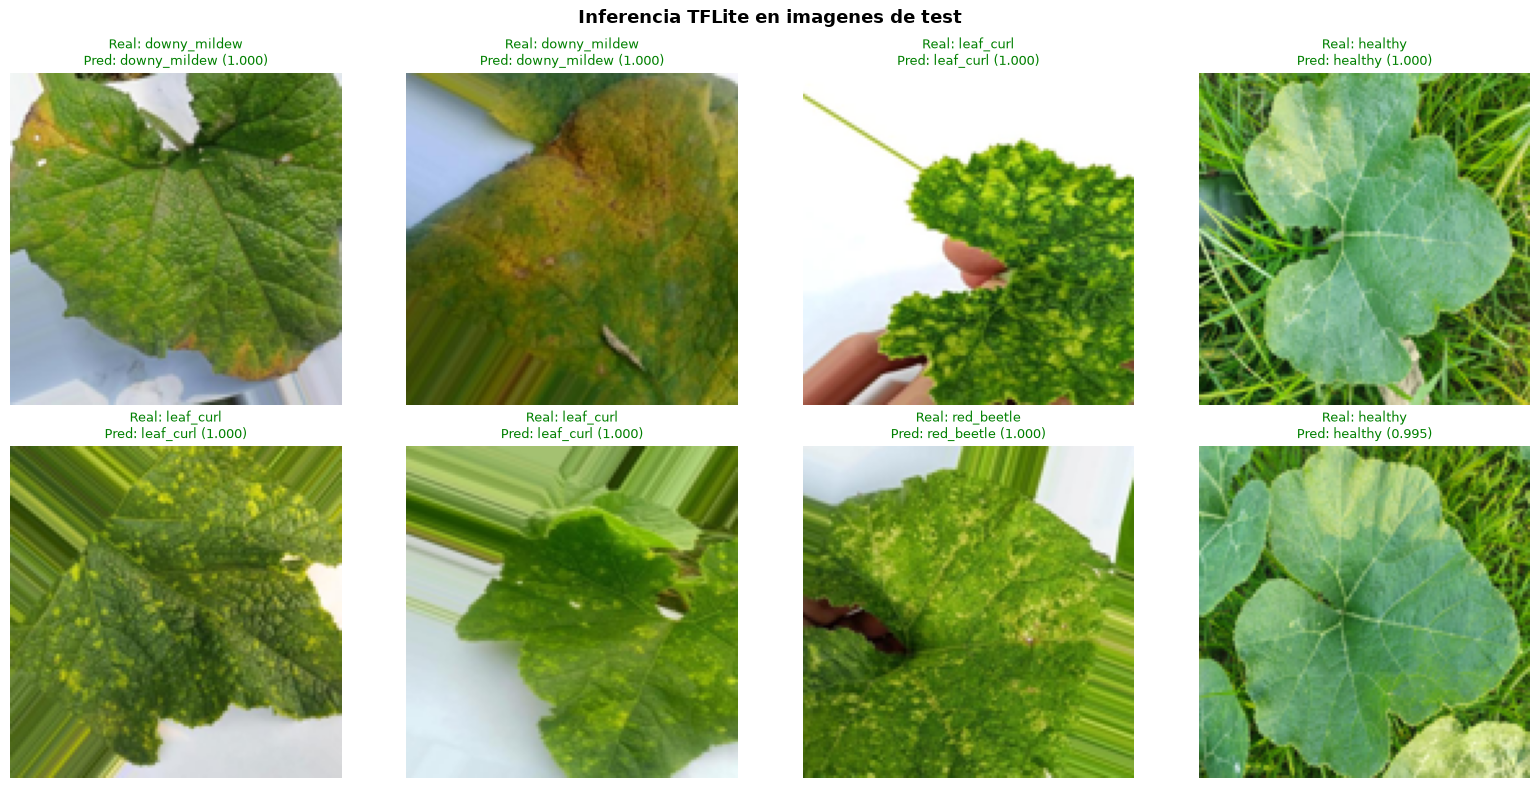

In [6]:
# ── 4. Ejemplos de inferencia en test set ───────────────────
import matplotlib.pyplot as plt
import random

print('Probando el modelo TFLite en imagenes de test...')

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
examples = []
for cls in CLASSES:
    cls_dir = PROCESSED_DIR / 'test' / cls
    if not cls_dir.exists():
        continue
    imgs = list(cls_dir.glob('*.jpg'))[:3]
    for p in imgs:
        examples.append((p, cls))

random.shuffle(examples)

for i, (img_path, true_cls) in enumerate(examples[:8]):
    ax = axes[i // 4][i % 4]
    
    pred_cls, confidence, probs = predict(img_path)
    
    with Image.open(img_path) as raw:
        img = raw.convert('RGB').resize((128, 128))
    ax.imshow(img)
    
    color = 'green' if pred_cls == true_cls else 'red'
    title = f'Real: {true_cls}\nPred: {pred_cls} ({confidence:.3f})'
    ax.set_title(title, fontsize=9, color=color)
    ax.axis('off')

plt.suptitle('Inferencia TFLite en imagenes de test',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
plt.close(fig)


Midiento latencia en 250 imagenes...

Benchmark TFLite (250 muestras):
  Media    : 12.6 ms
  Mediana  : 11.6 ms
  Std      : 3.1 ms
  Min      : 10.3 ms
  Max      : 47.0 ms
  P99      : 19.4 ms


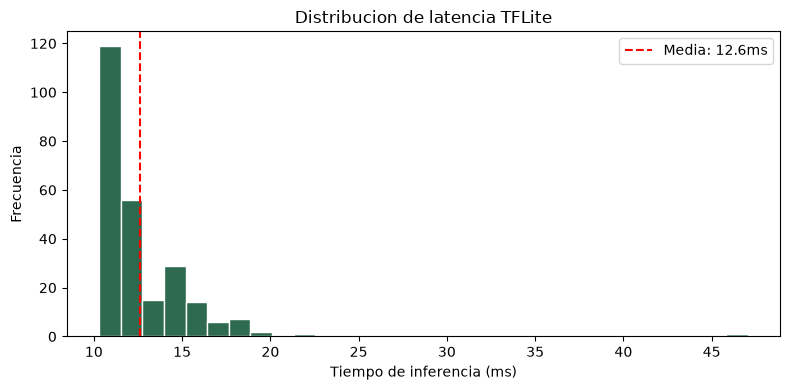

In [10]:
# ── 5. Metricas de latencia ─────────────────────────────────
import time

# Recolectar paths de test
test_imgs = []
for cls in CLASSES:
    cls_dir = PROCESSED_DIR / 'test' / cls
    if cls_dir.exists():
        test_imgs.extend(list(cls_dir.glob('*.jpg'))[:50])

print(f'Midiento latencia en {len(test_imgs)} imagenes...')

# Warmup
for _ in range(5):
    predict(random.choice(test_imgs))

# Benchmark
times = []
for img_path in test_imgs:
    t0 = time.perf_counter()
    predict(img_path)
    times.append(time.perf_counter() - t0)

times_ms = np.array(times) * 1000
print(f'\nBenchmark TFLite ({len(times)} muestras):')
print(f'  Media    : {times_ms.mean():.1f} ms')
print(f'  Mediana  : {np.median(times_ms):.1f} ms')
print(f'  Std      : {times_ms.std():.1f} ms')
print(f'  Min      : {times_ms.min():.1f} ms')
print(f'  Max      : {times_ms.max():.1f} ms')
print(f'  P99      : {np.percentile(times_ms, 99):.1f} ms')

# Histograma
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(times_ms, bins=30, color='#2D6A4F', edgecolor='white')
ax.axvline(times_ms.mean(), color='red', linestyle='--',
           label=f'Media: {times_ms.mean():.1f}ms')
ax.set_xlabel('Tiempo de inferencia (ms)')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribucion de latencia TFLite')
ax.legend()
plt.tight_layout()
plt.show()
plt.close(fig)


In [8]:
# ── 6. Verificar consistencia labels.txt ────────────────────
print('=== Verificacion de labels.txt ===')

labels_desde_archivo = labels  # cargado al inicio
print(f'labels.txt        : {labels_desde_archivo}')
print(f'config.CLASSES    : {CLASSES}')

if labels_desde_archivo == CLASSES:
    print('\nConsistentes. El orden coincide con YOLO.')
else:
    print('\nINCONSISTENCIA. Revisar train.py (labels.txt).')
    print(f'  Diferencia: {set(labels_desde_archivo) ^ set(CLASSES)}')

# Verificar output del modelo
print(f'\nOutput del modelo TFLite:')
print(f'  {len(labels)} clases: {labels}')
print(f'  Indices del output corresponden a este orden.')
print()
print('En Flutter, la app lee labels.txt y mapea el indice del modelo')
print('a la etiqueta de texto. Coherente con YOLOv11n-cls.')


=== Verificacion de labels.txt ===
labels.txt        : ['downy_mildew', 'healthy', 'leaf_curl', 'mosaic_virus', 'red_beetle']
config.CLASSES    : ['downy_mildew', 'healthy', 'leaf_curl', 'mosaic_virus', 'red_beetle']

Consistentes. El orden coincide con YOLO.

Output del modelo TFLite:
  5 clases: ['downy_mildew', 'healthy', 'leaf_curl', 'mosaic_virus', 'red_beetle']
  Indices del output corresponden a este orden.

En Flutter, la app lee labels.txt y mapea el indice del modelo
a la etiqueta de texto. Coherente con YOLOv11n-cls.


In [9]:
# ── 7. Resumen final ────────────────────────────────────────
print('=== RESUMEN DESPLIEGUE ZapalloAI ===')
print(f'Modelo TFLite : {tflite_path.name}')
print(f'  Tamaño      : {tflite_path.stat().st_size / 1024**2:.2f} MB')
print(f'  Input       : {input_shape}')
print(f'  Output      : {len(labels)} clases')
print(f'  Latencia    : {times_ms.mean():.1f} ms (media)')
print()
print('Archivos para Flutter:')
print(f'  - {FLUTTER_TFLITE}')
print(f'  - {FLUTTER_LABELS}')
print()
print('Flujo completo:')
print('  1. python model/scripts/preprocess.py    # preparar datos')
print('  2. python model/scripts/train.py         # entrenar + exportar')
print('  3. Abrir notebooks para EDA, eval, test')
print('  4. flutter build apk --release            # compilar app')


=== RESUMEN DESPLIEGUE ZapalloAI ===
Modelo TFLite : best_int8.tflite
  Tamaño      : 1.57 MB
  Input       : [  1 224 224   3]
  Output      : 5 clases
  Latencia    : 13.0 ms (media)

Archivos para Flutter:
  - D:\zapallo-vision\zapallo_app\assets\models\best_int8.tflite
  - D:\zapallo-vision\zapallo_app\assets\models\labels.txt

Flujo completo:
  1. python model/scripts/preprocess.py    # preparar datos
  2. python model/scripts/train.py         # entrenar + exportar
  3. Abrir notebooks para EDA, eval, test
  4. flutter build apk --release            # compilar app
